In [161]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt

## Problems

### Scoring

-   Problem 1 is worth 10 points;
-   Problem 2 is worth 15 points;

### Problem 1

Let’s examine the influence of global temperature change on the blooming
day of cherry blossoms in Kyoto. While these dates are discrete, we will
use a linear regression model relating the day to the global mean
temperature anomaly for March (the third non-year column in
`data/HadCRUT5.1Analysis_gl.txt`).

#### Problem 1.1

Load the data and fit this model. What does your fitted model suggest as
the influence of March temperature anomalies on the cherry blossom date?

In [146]:
blossoms = pd.read_csv("data/kyoto.csv")
blossoms = blossoms[blossoms["Year.AD"] > 1850].reset_index(drop=True)

In [158]:
years_na_blooms = np.where(blossoms[' Flowering.DOY'].isna())[0]
blossoms = blossoms.drop(years_na_blooms).reset_index(drop=True)

In [159]:
temp_dat = pd.read_csv("data/HadCRUT5.1Analysis_gl.txt", sep="\\s+", 
    names=["Year", "January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December", "Annual"])
stop = temp_dat.index[temp_dat["Year"]==2015][1]
temps = temp_dat[:stop:2].reset_index(drop=True)
temps = temps[1:].reset_index(drop=True)
temps = temps.drop(years_na_blooms).reset_index(drop=True)

In [160]:
model = sklearn.linear_model.LinearRegression()
model.fit(pd.DataFrame(temps["March"]), pd.DataFrame(blossoms[" Flowering.DOY"]))

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [180]:
model.coef_[0][0]

np.float64(-7.773816956010837)

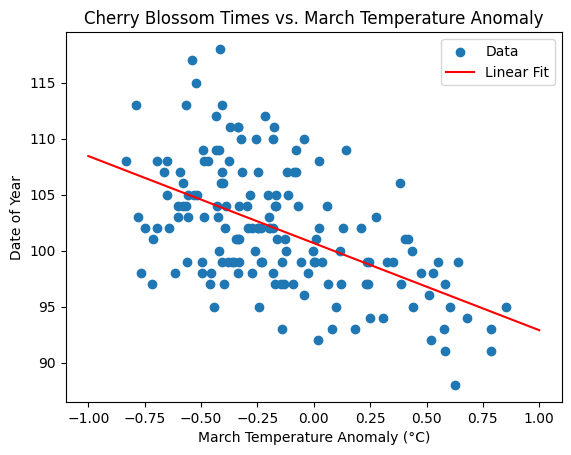

In [179]:
plt.scatter(temps["March"], blossoms[" Flowering.DOY"], label="Data")
x = np.linspace(-1, 1, 100)
plt.plot(x, (model.coef_[0][0]*x)+model.intercept_[0], "r-", label="Linear Fit")
plt.legend()
plt.xlabel("March Temperature Anomaly (°C)")
plt.ylabel("Date of Year")
plt.title("Cherry Blossom Times vs. March Temperature Anomaly")
plt.savefig("figs/11.png")

#### Problem 1.2

Calculate the log-loss (negative log-probability) and mean-squared error
metrics for the fitted model on the in-sample data.

In [195]:
sklearn.metrics.mean_squared_error(pd.DataFrame(blossoms[" Flowering.DOY"]), model.predict(pd.DataFrame(temps["March"])))

22.316707714914653

#### Problem 1.3

Conduct a 5-fold cross-validation for the model using both of these
metrics. How do they compare to the in-sample metrics?

In [200]:
sklearn.model_selection.cross_val_score(sklearn.linear_model.LinearRegression(), 
    pd.DataFrame(temps["March"]), 
    pd.DataFrame(blossoms[" Flowering.DOY"]), 
    cv=5,
    scoring="neg_mean_squared_error")

array([-34.675388  , -23.14703813, -20.46070791, -22.81506239,
       -18.74007898])

### Problem 2

Let’s re-examine the influence of air pollution and temperature on
mortality in Chicago, IL. The `data/chicago.csv` dataset (originally
from the [`gamair` `R`
package](https://cran.r-project.org/web/packages/gamair/index.html))contains
data on the relationship between environmental conditions (temperature
and air quality) and deaths in Chicago from 1987–2000. The variables
are:

-   the total number of (non-accidental) deaths each day (`death`);
-   the median density over the city of large pollutant particles (PM10;
    `pm10median`);
-   the median density of smaller pollutant particles (PM2.5;
    `pm25median`);
-   the median concentration of ozone (O$_3$) in the air (`o3median`);
    the median concentration of sulfur dioxide (SO$_2$) in the air
    (`so2median`);
-   the time in days (`time`); and the daily mean temperature (`tmpd`).

The pollution variables have been standardized to represent deviations
from the overall median and the temperature is in Fahrenheit. The days
are given as a number of days relative to December 31, 1993. Note that
some values are missing; these can be treated as missing at random and
dropped in your regressions.

In [220]:
chi = pd.read_csv("data/chicago.csv", index_col="idx")

In [221]:
chi["date"] = pd.to_datetime("1993-12-31") + pd.to_timedelta(chi.time, "day")

In [231]:
chi

,death,pm10median,pm25median,o3median,so2median,time,tmpd,date
idx,,,,,,,,
1,130,-7.433544,NaN,-19.592338,1.928043,-2556.5,31.5,1986-12-31 12:00:00
2,150,NaN,NaN,-19.038614,-0.985563,-2555.5,33.0,1987-01-01 12:00:00
3,101,-0.826531,NaN,-20.217338,-1.891416,-2554.5,33.0,1987-01-02 12:00:00
4,135,5.566456,NaN,-19.675671,6.139341,-2553.5,29.0,1987-01-03 12:00:00
5,126,NaN,NaN,-19.217338,2.278465,-2552.5,32.0,1987-01-04 12:00:00
...,...,...,...,...,...,...,...,...
5110,119,-9.123944,10.988615,-13.274541,1.673339,2552.5,12.0,2000-12-26 12:00:00
5111,125,-12.123944,5.288615,-11.179778,2.618337,2553.5,13.0,2000-12-27 12:00:00
5112,132,-3.123944,0.525000,-6.036201,4.931991,2554.5,21.0,2000-12-28 12:00:00


#### Problem 2.1

Load and plot the deaths data. Linearly regress the number of deaths
against time and report the coefficients for the fitted model. Add the
regression line to your plot. What does this regression tell you?

In [296]:
model = sklearn.linear_model.LinearRegression()
model.fit(pd.DataFrame(chi["date"]), pd.DataFrame(chi["death"]))
print(model.coef_[0][0], model.intercept_[0])

-1.7600693798433622e-17 128.7477852258744


/opt/anaconda3/envs/weather_plots/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


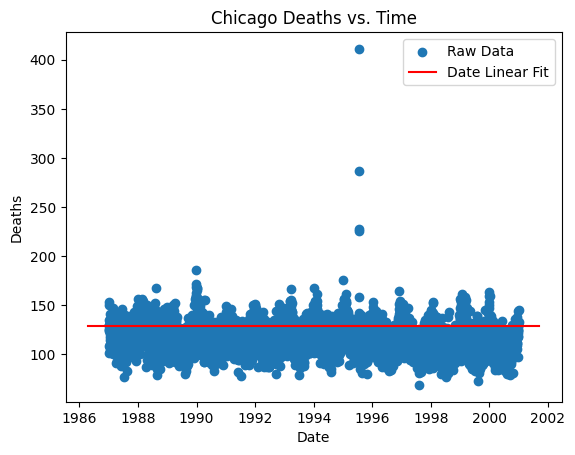

In [297]:
plt.scatter(chi["date"], chi["death"], label="Raw Data")
plt.xlabel("Date")
plt.ylabel("Deaths")
plt.title("Chicago Deaths vs. Time")
x = np.linspace(plt.xlim()[0], plt.xlim()[1], 100)
plt.plot(x, model.predict(x.reshape(-1, 1)), "r-", label="Date Linear Fit")
plt.legend()
plt.savefig("figs/21.png")

#### Problem 2.2

Now linearly regress the deaths data against temperature. Once again,
report the coefficients, and add the regression line to your plot. What
does this regression tell you about the influence of temperature?

In [300]:
model = sklearn.linear_model.LinearRegression()
model.fit(pd.DataFrame(chi["tmpd"]), pd.DataFrame(chi["death"]))
print(model.coef_[0][0], model.intercept_[0])

-0.2896442961500986 129.9570512147682


/opt/anaconda3/envs/weather_plots/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


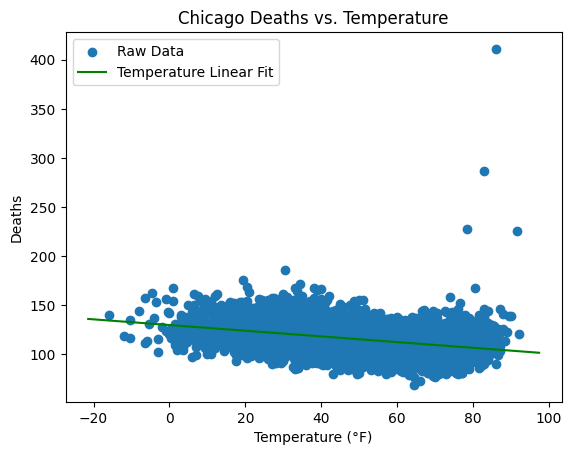

In [301]:
plt.scatter(chi["tmpd"], chi["death"], label="Raw Data")
plt.xlabel("Temperature (°F)")
plt.ylabel("Deaths")
plt.title("Chicago Deaths vs. Temperature")
x = np.linspace(plt.xlim()[0], plt.xlim()[1], 100)
plt.plot(x, model.predict(x.reshape(-1,1)), "g-", label="Temperature Linear Fit")
plt.legend()
plt.savefig("figs/22.png")

In [302]:
chi_cut = chi[['tmpd', "pm25median", "death"]].dropna()

In [303]:
model_new = sklearn.linear_model.LinearRegression()
model_new.fit(chi_cut[['tmpd', "pm25median"]], pd.DataFrame(chi_cut["death"]))
print(model_new.coef_[0], model_new.intercept_[0])

[-0.37111818  0.21532754] 129.29393325279526


/opt/anaconda3/envs/weather_plots/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/weather_plots/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


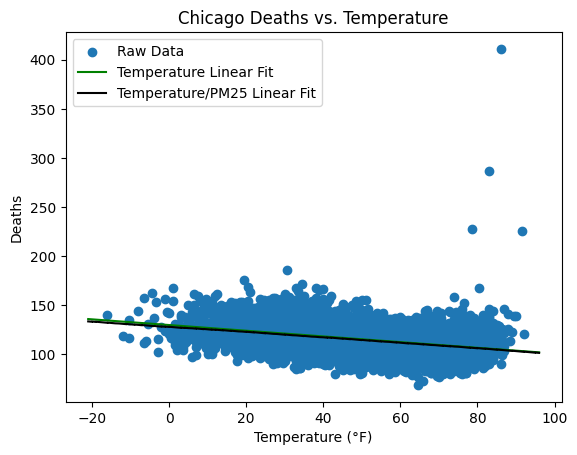

In [340]:
plt.scatter(chi["tmpd"], chi["death"], label="Raw Data")
plt.xlabel("Temperature (°F)")
plt.ylabel("Deaths")
plt.title("Chicago Deaths vs. Temperature")
x = np.sort(np.random.randint(plt.xlim()[0], plt.xlim()[1], 1000))
x2 = np.sort(np.random.randint(chi["pm25median"].min(), chi["pm25median"].max(), 1000))
plt.plot(x, model.predict(x.reshape(-1,1)), "g-", label="Temperature Linear Fit")
plt.plot(x, model_new.predict(np.stack([x, x2], axis=1)), "k-", label="Temperature/PM25 Linear Fit")
plt.legend()
plt.savefig("figs/23.png")

In [341]:
sklearn.model_selection.cross_val_score(sklearn.linear_model.LinearRegression(), 
    pd.DataFrame(chi["tmpd"]), 
    pd.DataFrame(chi["death"]), 
    cv=5,
    scoring="neg_mean_squared_error")

array([-164.42797856, -170.08771888, -178.88082097, -321.36085279,
       -203.50699814])

In [345]:
sklearn.model_selection.cross_val_score(sklearn.linear_model.LinearRegression(), 
    chi_cut[["tmpd", "pm25median"]], 
    pd.DataFrame(chi_cut["death"]), 
    cv=5,
    scoring="neg_mean_squared_error")

array([-140.53480444, -170.12784263, -183.30495633, -150.66900383,
       -122.85507981])

In [347]:
aic = sklearn.linear_model.LassoLarsIC(criterion='aic')

In [348]:
aic.fit(chi_cut[["tmpd", "pm25median"]], 
    pd.DataFrame(chi_cut["death"]))

/opt/anaconda3/envs/weather_plots/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"criterion criterion: {'aic', 'bic'}, default='aic'The type of criterion to use.",'aic'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"verbose verbose: bool or int, default=FalseSets the verbosity amount.",False
,"precompute precompute: bool, 'auto' or array-like, default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=500Maximum number of iterations to perform. Can be used forearly stopping.",500
,"eps eps: float, default=np.finfo(float).epsThe machine-precision regularization in the computation of theCholesky diagonal factors. Increase this for very ill-conditionedsystems. Unlike the ``tol`` parameter in some iterativeoptimization-based algorithms, this parameter does not controlthe tolerance of the optimization.",np.float64(2....049250313e-16)
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"positive positive: bool, default=FalseRestrict coefficients to be >= 0. Be aware that you might want toremove fit_intercept which is set True by default.Under the positive restriction the model coefficients do not convergeto the ordinary-least-squares solution for small values of alpha.Only coefficients up to the smallest alpha value (``alphas_[alphas_ >0.].min()`` when fit_path=True) reached by the stepwise Lars-Lassoalgorithm are typically in congruence with the solution of thecoordinate descent Lasso estimator.As a consequence using LassoLarsIC only makes sense for problems wherea sparse solution is expected and/or reached.",False
,"noise_variance noise_variance: float, default=NoneThe estimated noise variance of the data. If `None`, an unbiasedestimate is computed by an OLS model. However, it is only possiblein the case where `n_samples > n_features + fit_intercept`... versionadded:: 1.1",None
